## import

In [105]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
import seaborn as sns

## train

In [112]:
food_reward_list = np.linspace(555,2222,5)
att_coeff = 0.087213 #0.087213
att_temp = 0.25 # 0.25
penalty_cost = -30 #  -30
time_in_game_reward = 0. # old 0

## food reward as a paramter input

In [113]:
task=AFR2()
task.food_reward_list=food_reward_list
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


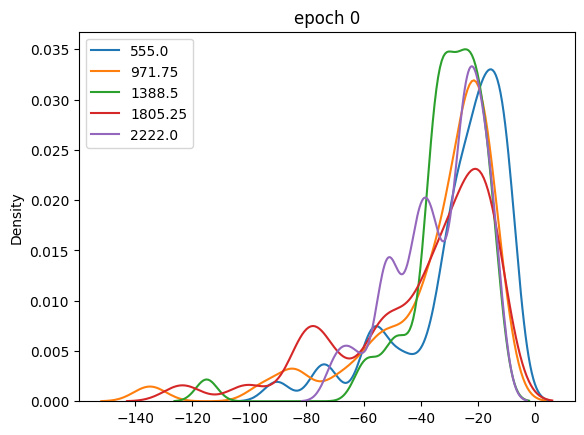

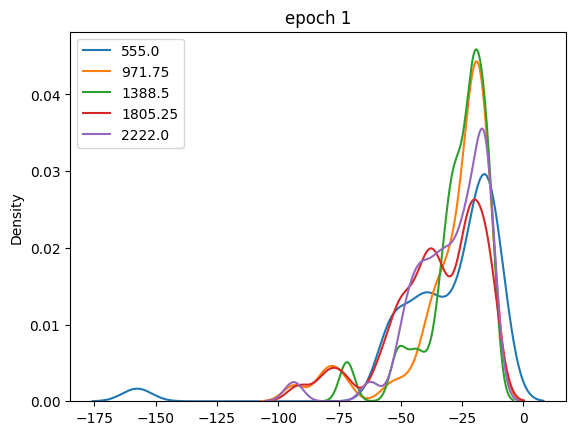

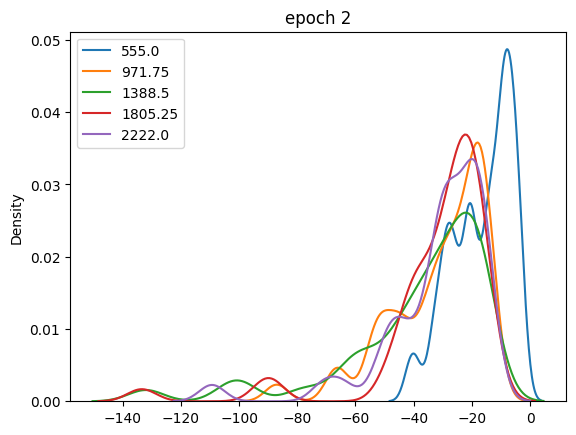

/tmp/ipykernel_1374530/4143329379.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)
/tmp/ipykernel_1374530/4143329379.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)
/tmp/ipykernel_1374530/4143329379.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)


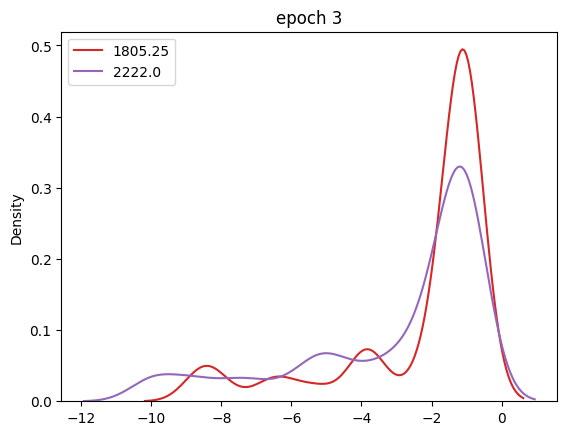

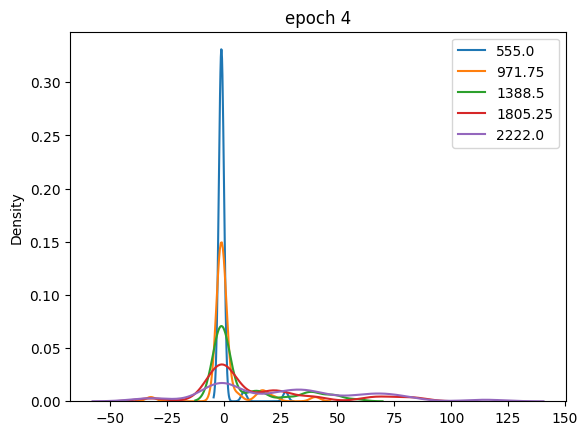

/tmp/ipykernel_1374530/4143329379.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)
/tmp/ipykernel_1374530/4143329379.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)


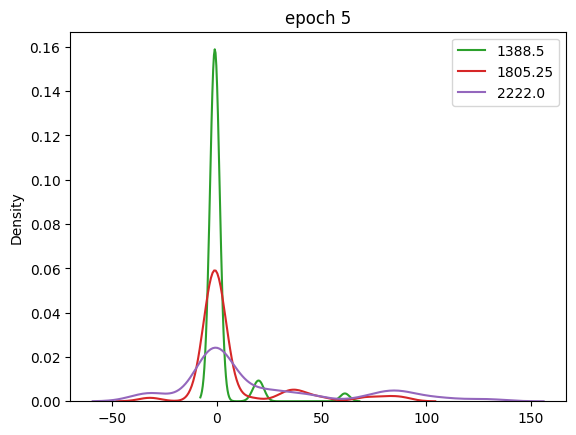

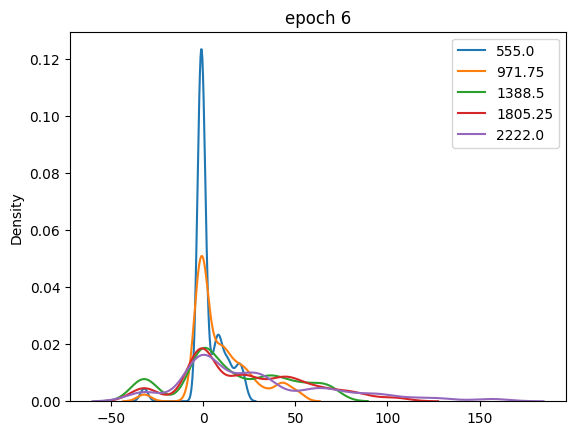

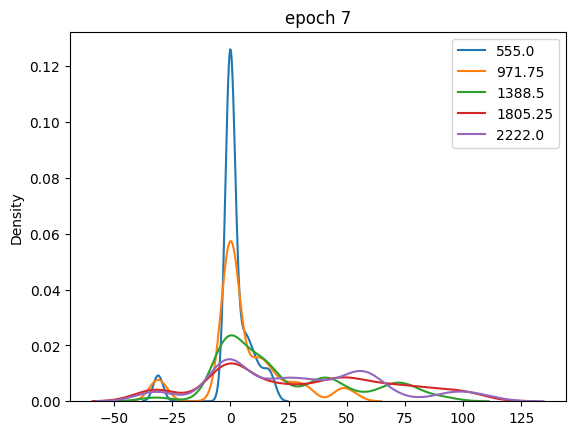

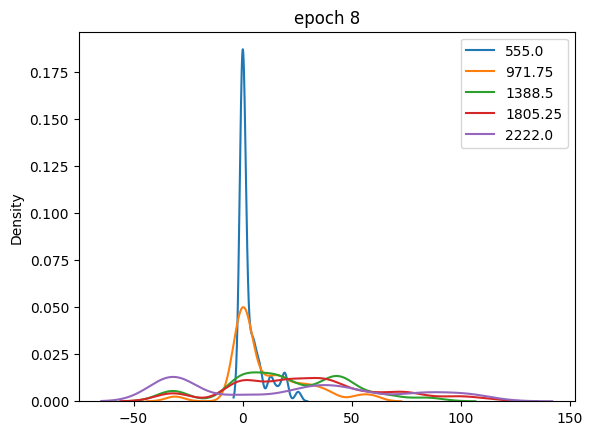

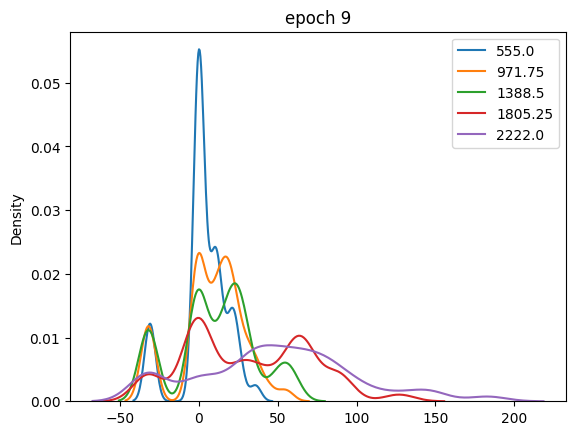

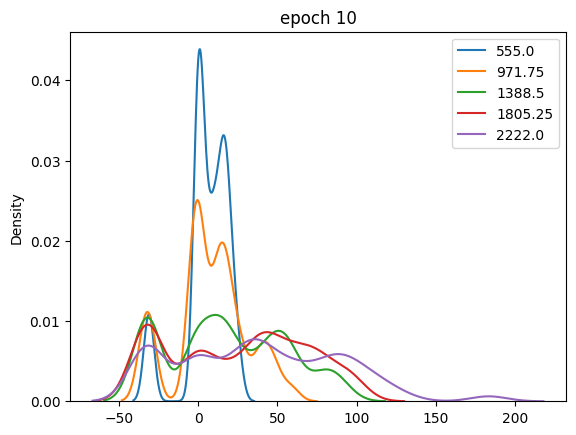

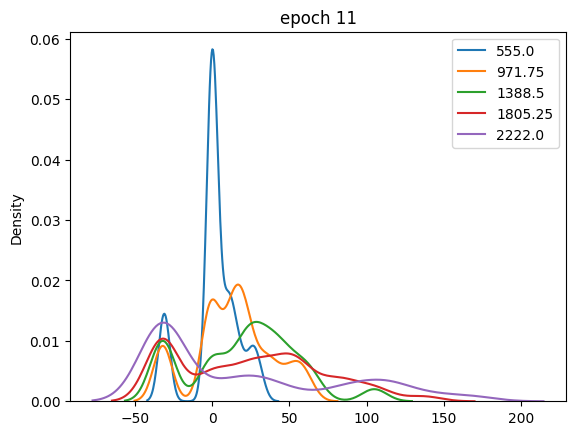

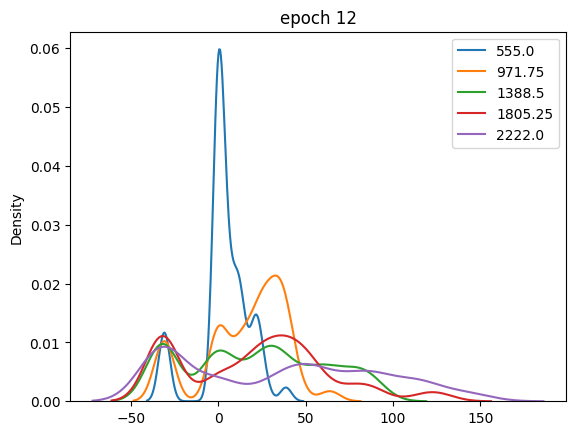

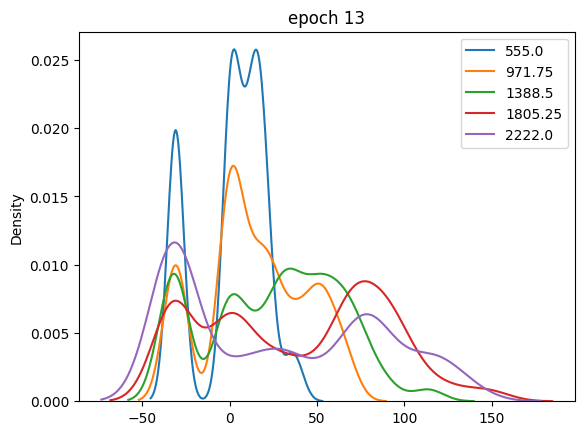

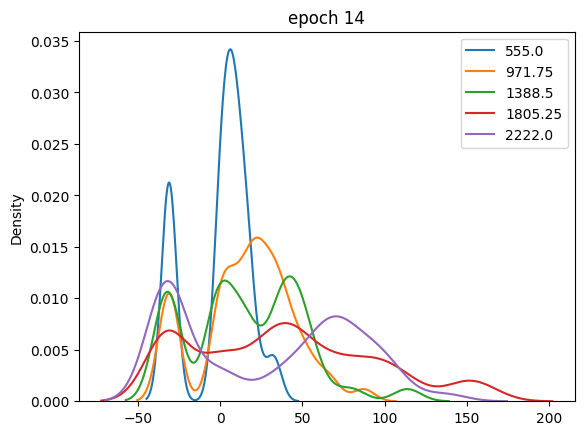

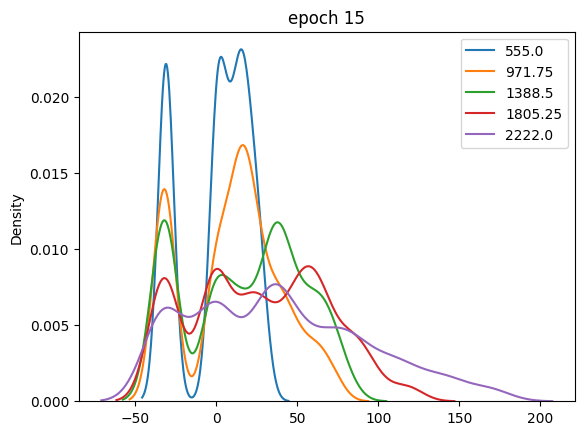

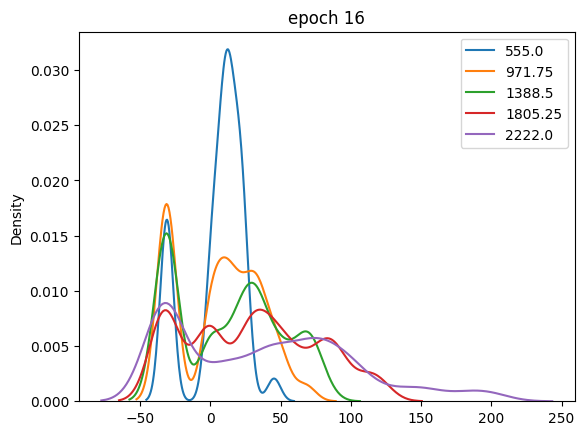

KeyboardInterrupt: 

In [114]:
# train
for i in range(222):
    model.learn(total_timesteps=4444)

    # eval
    history_r=defaultdict(list)
    for _ in range(222):
        t=0
        total_r=0 # trial total reward
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r # updating trial total reward
        # print(total_r)
        history_r[taskbelief.env.food_reward].append(total_r) 
        
    for k in sorted(history_r.keys()):
        v=history_r[k]
        # _=plt.hist(v, bins=22, label=k, alpha=0.3, density=True)
        sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)
    plt.legend()
    plt.title(f'epoch {i}')
    plt.show()

## save

In [3]:
# model.save('ycstore/v2')
model=PPO.load('ycstore/v2', env=taskbelief)

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


## some check of var shape

In [4]:
# taskbelief.belief is the observation
taskbelief.observation_space, taskbelief.action_space, taskbelief.belief.shape

(Box(-inf, inf, (29,), float32), MultiDiscrete([2 2]), (29,))

In [5]:
taskbelief.reset()
task.food_reward=1100 # the actual task is by reference
taskbelief.env.observation_space, taskbelief.env.food_reward, task.food_reward, taskbelief.belief

(MultiDiscrete([4]),
 1100,
 1100,
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.83333333]))

In [6]:
taskbelief.reset(return_info=True) # how taskbelief call task reset?

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 {'observation': (3,), 'state': (27,)})

In [7]:
np.concatenate([taskbelief.belief, [1000]])

array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          1.,    0., 1000.])

In [ ]:
model.policy

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=29, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=29, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=4, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

## helper function

In [115]:
def run_one_episode(task, taskbelief, agent,
    num_steps= 40,
    q_states= [[i] for i in range(task.no_nodes)]):

    actions, rewards, states, observations, beliefs = [], [], [], [], []
    trial_food_reward=[]

    get_queries = lambda env: q_states
    try:
        _q_states = get_queries(taskbelief.env)
        _q_states, _q_probs = [], []
    except:
        get_queries = None


    belief, info = taskbelief.reset(task, return_info=True)
    states.append(info['state'])
    observations.append(info['observation'])
    beliefs.append(belief)
    if get_queries is not None:
        _q_states.append(np.array(get_queries(taskbelief.env)))
        _q_probs.append(taskbelief.query_probs(_q_states[-1]))
    t = 0
    while True:

        action, _ = agent.predict(belief, deterministic=True)

        action = action

        actions.append(action)
        belief, reward, done, info =taskbelief.step(action, task)
        rewards.append(reward)
        states.append(info['state'])
        observations.append(info['observation'])
        beliefs.append(belief)
        if get_queries is not None:
            _q_states.append(np.array(get_queries(taskbelief.env)))
            _q_probs.append(taskbelief.query_probs(_q_states[-1]))
        t += 1
        if done or t==num_steps:
            break
    
    episode = {
        'trial_food_reward_idx':task.food_reward_idx,
        'num_steps': t,
        'actions': np.array(actions), # [0, t)
        'rewards': np.array(rewards), # [0, t)
        'states': np.array(states), # [0, t]
        'observations': np.array(observations), # [0, t]
        'beliefs': np.array(beliefs), # [0, t]
    }

    if get_queries is not None:
        diffs = ((_q_states-_q_states[0])**2).reshape(len(_q_states), -1).sum(axis=1)
        if np.all(diffs<1e-8): # merge fixed query set
            _q_states = _q_states[0]
        episode['q_states'] = np.array(_q_states) # (num_queries, state_dim, t+1) or (num_queries, state_dim)
        episode['q_probs'] = np.array(_q_probs) # (num_queries, t+1)

    return episode


In [116]:
def count_no_elements(np_array, min_allowed, max_allowed):
    return len([elt for elt in list(np_array.flatten()) if elt >= min_allowed and elt <= max_allowed])

In [119]:
def process_one_episode(episode):
    hit_count = 0
    miss_count = 0
    false_alarm_count = 0
    noise_time_before_lick = 0
    signal_time_before_lick = 0
    total_noise_time = 0
    total_signal_time = 0
    total_reward = 0

    attention_time_points_across_episodes = []
    episode_length_across_episodes = []
    hit_reaction_time_across_episodes = []
    fa_reaction_time_across_episodes = []

    # process single ep data
    if episode['actions'][-1][0] == 1:
        if episode['states'][-1][0] > task.no_signal_nodes + task.no_penalty_nodes:
            hit_count += 1
            signal_time_before_lick_curr_episode = count_no_elements(
                episode['states'], 1, task.no_signal_nodes)
            hit_reaction_time_across_episodes.append(
                signal_time_before_lick_curr_episode)
            signal_time_before_lick += signal_time_before_lick_curr_episode
        else:
            false_alarm_count += 1
            noise_time_before_lick_curr_episode = count_no_elements(
                episode['states'], 0, 0)
            fa_reaction_time_across_episodes.append(
                noise_time_before_lick_curr_episode)
            noise_time_before_lick += noise_time_before_lick_curr_episode
    else:
        miss_count += 1
    total_signal_time += count_no_elements(
        episode['states'], 1, task.no_signal_nodes)
    total_noise_time += count_no_elements(episode['states'], 0, 0)
    total_reward += sum(episode['rewards'])
    # attention_time_points_across_episodes.append(np.where(episode['actions'] % env.no_attention_modes > 0)[0])
    attention_time_points_across_episodes.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    episode_length_across_episodes.append(len(episode['states']))
    # end process single ep data
    food_reward_idx = episode['trial_food_reward_idx']
    return (food_reward_idx,  
            hit_count,
            miss_count, 
            false_alarm_count, 
            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,
            total_reward,
            attention_time_points_across_episodes ,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes ,
            fa_reaction_time_across_episodes
            )

In [117]:
no_episodes=999*10

hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]
noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]
best_seed_list = [[0] for _ in range(len(food_reward_list))]

for episide_no in range(no_episodes):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,num_steps=100000, q_states = [[i] for i in range(task.no_nodes)])


    hit_count = 0 
    miss_count = 0 
    false_alarm_count = 0 
    noise_time_before_lick = 0 
    signal_time_before_lick = 0 
    total_noise_time = 0 
    total_signal_time = 0
    total_reward = 0

    attention_time_points_across_episodes = []
    episode_length_across_episodes = []
    hit_reaction_time_across_episodes = []
    fa_reaction_time_across_episodes = []

    # process single ep data
    if episode['actions'][-1][0] == 1:
        if episode['states'][-1][0] > task.no_signal_nodes + task.no_penalty_nodes:
            hit_count += 1
            signal_time_before_lick_curr_episode = count_no_elements(episode['states'], 1, task.no_signal_nodes)
            hit_reaction_time_across_episodes.append(signal_time_before_lick_curr_episode)
            signal_time_before_lick += signal_time_before_lick_curr_episode
        else:
            false_alarm_count += 1
            noise_time_before_lick_curr_episode = count_no_elements(episode['states'], 0, 0)
            fa_reaction_time_across_episodes.append(noise_time_before_lick_curr_episode)
            noise_time_before_lick += noise_time_before_lick_curr_episode
    else:
        miss_count += 1                            
    total_signal_time += count_no_elements(episode['states'], 1, task.no_signal_nodes)
    total_noise_time += count_no_elements(episode['states'], 0, 0)
    total_reward += sum(episode['rewards'])
    # attention_time_points_across_episodes.append(np.where(episode['actions'] % env.no_attention_modes > 0)[0])
    attention_time_points_across_episodes.append(np.where(np.array([elt[1] for elt in episode['actions']] )== 1)[0])
    episode_length_across_episodes.append(len(episode['states']))
    # end process single ep data

    # log
    food_reward_idx=episode['trial_food_reward_idx']

    hit_count_list[food_reward_idx][0]+=(hit_count)
    miss_count_list[food_reward_idx][0]+=(miss_count)
    false_alarm_list[food_reward_idx][0]+=(false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0]+=(noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0]+=(signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0]+=(total_noise_time)
    total_signal_time_list[food_reward_idx][0]+=(total_signal_time)


## mp

In [127]:
# run mp job
no_episodes=9999
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                              num_steps=100000, q_states=[[i] for i in range(task.no_nodes)])
    food_reward_idx,              hit_count,            miss_count,             false_alarm_count,             noise_time_before_lick,            signal_time_before_lick,            total_noise_time,            total_signal_time,            total_reward,            attention_time_points_across_episodes,            episode_length_across_episodes,            hit_reaction_time_across_episodes,            fa_reaction_time_across_episodes = process_one_episode(
        episode)
    return (food_reward_idx,  
            hit_count,
            miss_count, 
            false_alarm_count, 
            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,
            total_reward,
            attention_time_points_across_episodes ,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes ,
            fa_reaction_time_across_episodes
            )
import multiprocessing
with multiprocessing.Pool(processes=13) as pool:
    results = pool.map(eval_wrapper, range(no_episodes))

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

for res in results:
    (food_reward_idx,  
            hit_count,
            miss_count, 
            false_alarm_count, 

            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,

            total_reward,
            
            attention_time_points_across_episodes ,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes ,
            fa_reaction_time_across_episodes
            )=res
    
    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0]+=(miss_count)
    false_alarm_list[food_reward_idx][0]+=(false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0]+=(noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0]+=(signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0]+=(total_noise_time)
    total_signal_time_list[food_reward_idx][0]+=(total_signal_time)

## plot

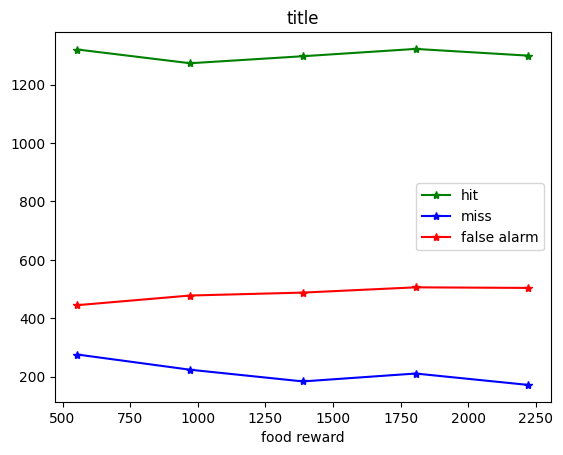

In [ ]:
def plot_hit_miss_FA(x_axis_list, hit_count_list, miss_count_list, false_alarm_list, title = ''):
    plt.figure()
    plt.plot(x_axis_list, hit_count_list, '-*g')
    plt.plot(x_axis_list, miss_count_list, '-*b')
    plt.plot(x_axis_list, false_alarm_list, '-*r')
    plt.legend(['hit', 'miss', 'false alarm'])
    plt.xlabel('food reward')
    plt.title(title)
    plt.show()

plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'title')

## mp with multi seed (agent)

In [155]:
# run mp job
signal_time_before_lick_list_list=[]
no_episodes=9999
for seed in range(10):
    
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, q_states=[[i] for i in range(task.no_nodes)])
        food_reward_idx,              hit_count,            miss_count,             false_alarm_count,             noise_time_before_lick,            signal_time_before_lick,            total_noise_time,            total_signal_time,            total_reward,            attention_time_points_across_episodes,            episode_length_across_episodes,            hit_reaction_time_across_episodes,            fa_reaction_time_across_episodes = process_one_episode(
            episode)
        return (food_reward_idx,  
                hit_count,
                miss_count, 
                false_alarm_count, 
                noise_time_before_lick,
                signal_time_before_lick,
                total_noise_time,
                total_signal_time,
                total_reward,
                attention_time_points_across_episodes ,
                episode_length_across_episodes,
                hit_reaction_time_across_episodes ,
                fa_reaction_time_across_episodes
                )
    with multiprocessing.Pool(processes=13) as pool:
        results = pool.map(eval_wrapper, range(no_episodes))

    # process the mp results
    hit_count_list = [[0] for _ in range(len(food_reward_list))]
    miss_count_list = [[0] for _ in range(len(food_reward_list))]
    false_alarm_list = [[0] for _ in range(len(food_reward_list))]

    noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
    total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
    total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

    for res in results:
        (food_reward_idx,  
                hit_count,
                miss_count, 
                false_alarm_count, 

                noise_time_before_lick,
                signal_time_before_lick,
                total_noise_time,
                total_signal_time,

                total_reward,
                
                attention_time_points_across_episodes ,
                episode_length_across_episodes,
                hit_reaction_time_across_episodes ,
                fa_reaction_time_across_episodes
                )=res
        
        hit_count_list[food_reward_idx][0] += (hit_count)
        miss_count_list[food_reward_idx][0]+=(miss_count)
        false_alarm_list[food_reward_idx][0]+=(false_alarm_count)

        noise_time_before_lick_list[food_reward_idx][0]+=(noise_time_before_lick)
        signal_time_before_lick_list[food_reward_idx][0]+=(signal_time_before_lick)
        total_noise_time_list[food_reward_idx][0]+=(total_noise_time)
        total_signal_time_list[food_reward_idx][0]+=(total_signal_time)

    signal_time_before_lick_list_list.append(signal_time_before_lick_list)

## plot

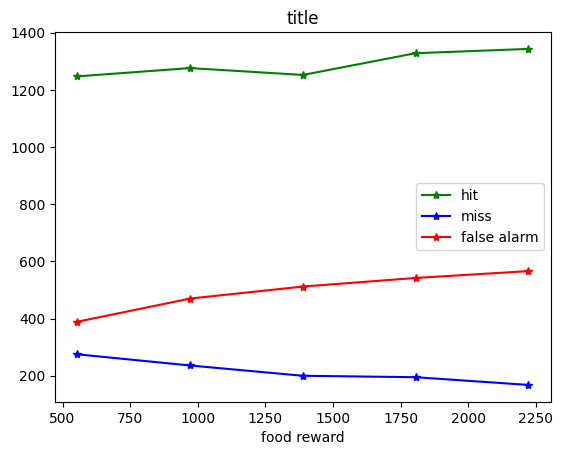

In [156]:
def plot_hit_miss_FA(x_axis_list, hit_count_list, miss_count_list, false_alarm_list, title = ''):
    plt.figure()
    plt.plot(x_axis_list, hit_count_list, '-*g')
    plt.plot(x_axis_list, miss_count_list, '-*b')
    plt.plot(x_axis_list, false_alarm_list, '-*r')
    plt.legend(['hit', 'miss', 'false alarm'])
    plt.xlabel('food reward')
    plt.title(title)
    plt.show()

plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'title')

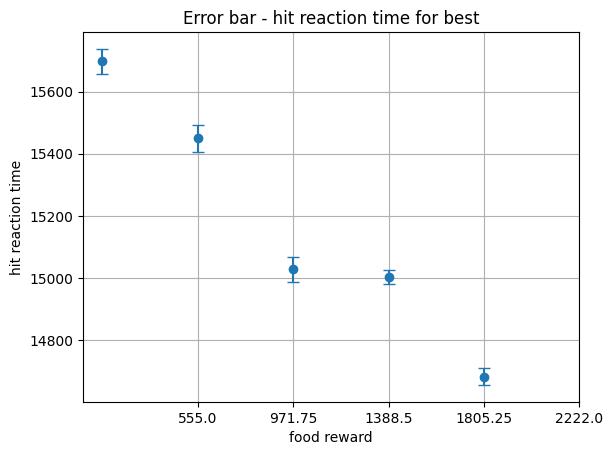

In [158]:
plt.figure()
tmp=np.array(signal_time_before_lick_list_list).reshape(10,5)
mean_list = np.mean(tmp, axis=0)
sem_list = np.std(tmp, axis=0)/np.size(tmp, axis=0)
plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
plt.xlabel('food reward')
plt.ylabel(f'hit reaction time')
plt.title(f'Error bar - hit reaction time for best')
plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
plt.grid()
plt.show()


## check

In [101]:
hit_count_list, miss_count_list, false_alarm_list

([[1249], [1256], [1266], [1192], [1242], [1199]],
 [[73], [60], [32], [21], [6], [3]],
 [[359], [422], [345], [399], [435], [440]])

In [102]:
noise_time_before_lick_list,signal_time_before_lick_list,total_noise_time_list,total_signal_time_list

([[13858], [16294], [13033], [14288], [15088], [16029]],
 [[11680], [11082], [11201], [9182], [8786], [8501]],
 [[52833], [57388], [53997], [49391], [52022], [52470]],
 [[13505], [12582], [12001], [9707], [8936], [8576]])

In [103]:
for k,v in episode.items():
    try:
        print(k, len(v))
    except:pass

actions 10
rewards 10
states 11
observations 11
beliefs 11
q_states 28
q_probs 11


## confirm the wrapper working for old env

In [ ]:
food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
num_epochs = 44
seed_value = 1

# for food_reward in food_reward_list:
#     task=AF()
#     task.food_reward=food_reward
#     model = PPO('MlpPolicy', task, verbose=1)
#     model.learn(total_timesteps=100)

task=AF()
task.food_reward=1500
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


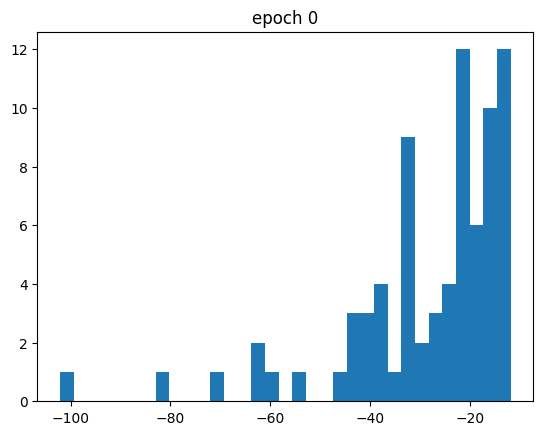

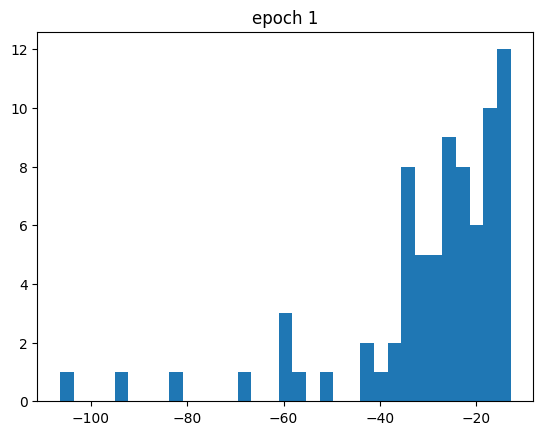

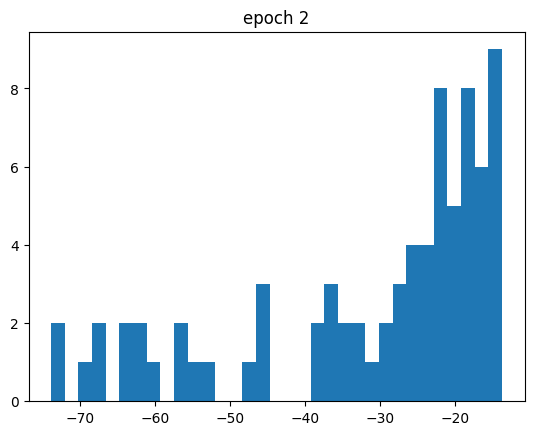

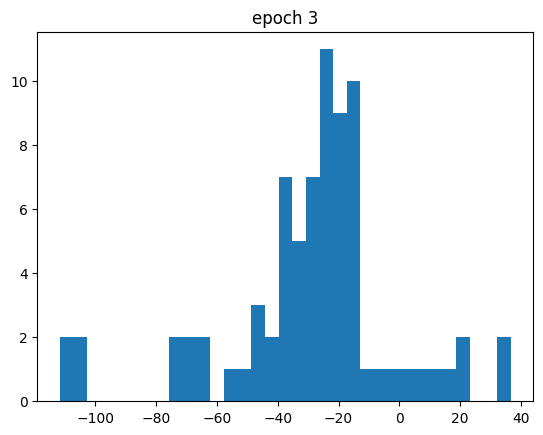

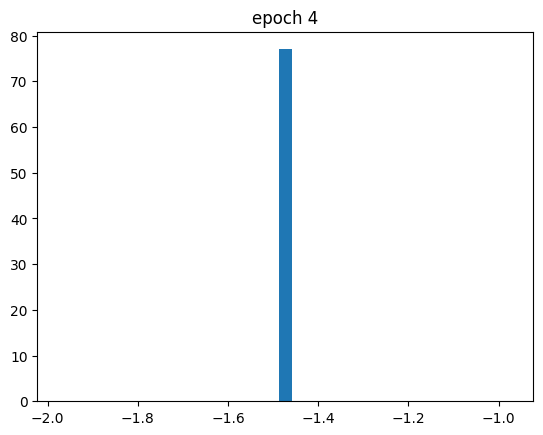

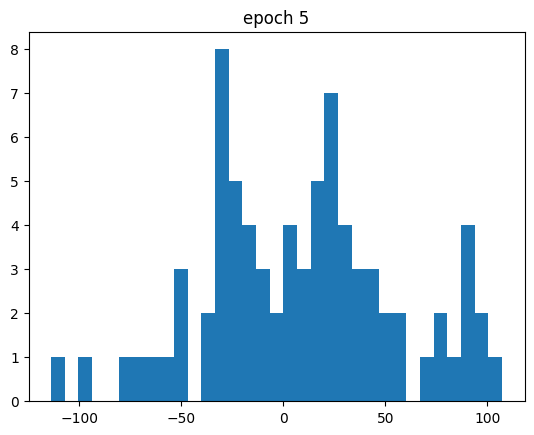

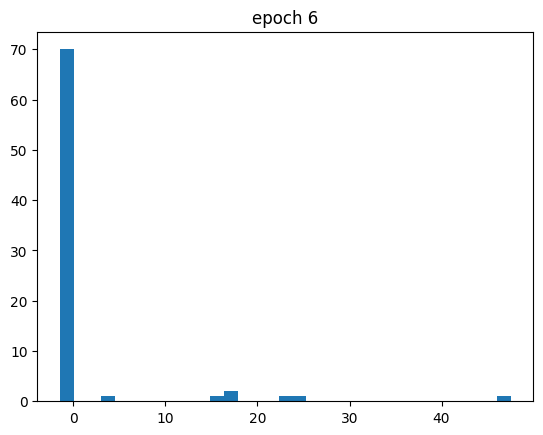

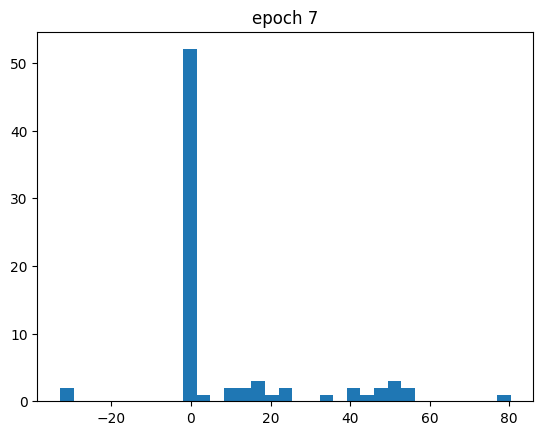

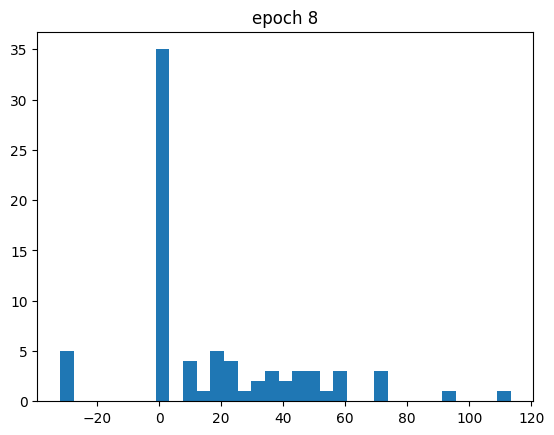

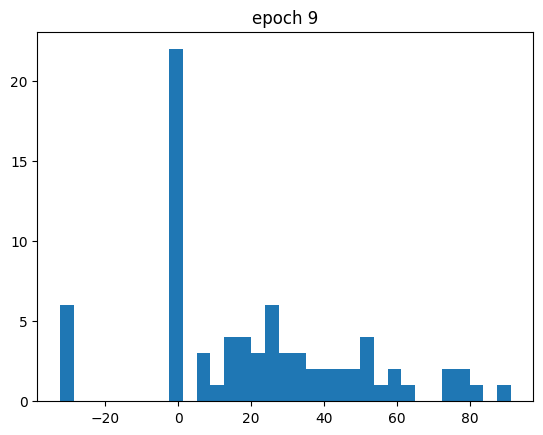

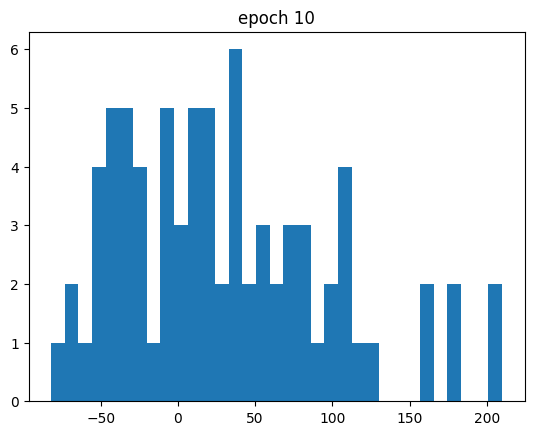

In [ ]:
# train
for i in range(11):
    model.learn(total_timesteps=2222)

    # eval
    history_r=[]
    for _ in range(77):
        t=0
        total_r=0
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r
        # print(total_r)
        history_r.append(total_r)

    _=plt.hist(history_r, bins=33)
    # history_r 
        # print(task.food_reward)
    plt.title(f'epoch {i}')
    plt.show()